# Wiederholung Statistik in der Qualitätssicherung: Notenverteilung

In diesem Notebook wiederholen wir die wichtigsten Inhalte aus der letzten Sitzung anhand eines Beispiels, das näher an der Gruppe ist als ein abstrakter Datensatz: **die Notenverteilung aus dem letzten Semester**.

**Ziele**

- Daten sauber einlesen und prüfen
- Häufigkeiten, Histogramm und Boxplot interpretieren
- Lage- und Streuungsmaße berechnen
- z-Werte verstehen
- Normalverteilung kritisch anwenden
- wichtige Verteilungen am Beispiel wiedererkennen

**Hinweis zur Interpretation:** Bei Noten ist ein kleinerer Wert besser. Das ist bei Mittelwert, z-Werten und Ausreißern wichtig.


## 1. Daten einlesen

Die Daten liegen hier absichtlich so vor, wie man sie häufig aus Excel kopiert: eine Note pro Zeile, mit deutschem Dezimalkomma.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import comb, erf, sqrt, pi, exp

In [3]:
daten_roh = """4,7
1
1,3
2,3
5
3
4
2,7
0,7
1
1,3
2
2
2,3
2
3
5
4,7
4
3,3
2,3
1
0,7
2,3
4,7
1,3
2,3
4,7
1,3
1,7
1,7
1,3
4,7
0,7
0,7
2,3
1,3
0,7
3,7
1
2,7
4,7
2,3
0,7
6
3,7
1,3
2,3
4
1
1
1,3
4
1,7
2,3
2,3
2,7"""

In [4]:
noten = [
    float(zeile.strip().replace(",", "."))
    for zeile in daten_roh.strip().splitlines()
    if zeile.strip()
]

In [5]:
df = pd.DataFrame({"Note": noten})

In [6]:
print(f"Anzahl der Noten: {len(df)}")

Anzahl der Noten: 57


In [7]:
df.head()

,Note
0,4.7
1,1.0
2,1.3
3,2.3
4,5.0


## 2. Erste Datenprüfung

Bevor man rechnet oder visualisiert, sollte man prüfen, ob die Werte plausibel sind.

Typische Fragen:

- Wie viele Beobachtungen gibt es?
- Gibt es fehlende Werte?
- Welche Noten kommen überhaupt vor?
- Gibt es auffällige Werte?


In [8]:
print("Anzahl Beobachtungen:", len(df))
print("Fehlende Werte:", df["Note"].isna().sum())
print("Kleinste Note:", df["Note"].min())
print("Größte Note:", df["Note"].max())

print("\nSortierte eindeutige Noten:")
print(sorted(df["Note"].unique()))


Anzahl Beobachtungen: 57
Fehlende Werte: 0
Kleinste Note: 0.7
Größte Note: 6.0

Sortierte eindeutige Noten:
[0.7, 1.0, 1.3, 1.7, 2.0, 2.3, 2.7, 3.0, 3.3, 3.7, 4.0, 4.7, 5.0, 6.0]


## 3. Häufigkeitstabelle

Für Noten ist eine Häufigkeitstabelle oft aussagekräftiger als nur Mittelwert und Standardabweichung. Man sieht direkt, welche Noten häufig oder selten vorkommen.


In [9]:
# Mögliche Notenskala. 4.3 ist enthalten, auch wenn diese Note in den Daten nicht vorkommt.
notenskala = [0.7, 1.0, 1.3, 1.7, 2.0, 2.3, 2.7, 3.0, 3.3, 3.7, 4.0, 4.3, 4.7, 5.0, 6.0]

freq = (
    df["Note"]
    .value_counts()
    .reindex(notenskala, fill_value=0)
    .rename_axis("Note")
    .reset_index(name="Anzahl")
)

freq["Anteil"] = freq["Anzahl"] / len(df)
freq["Anteil_%"] = (100 * freq["Anteil"]).round(1)
freq["kumuliert_%"] = (100 * freq["Anteil"].cumsum()).round(1)

display(freq)


,Note,Anzahl,Anteil,Anteil_%,kumuliert_%
0,0.7,6,0.105263,10.5,10.5
1,1.0,6,0.105263,10.5,21.1
2,1.3,8,0.140351,14.0,35.1
3,1.7,3,0.052632,5.3,40.4
4,2.0,3,0.052632,5.3,45.6
5,2.3,10,0.175439,17.5,63.2
6,2.7,3,0.052632,5.3,68.4
7,3.0,2,0.035088,3.5,71.9
8,3.3,1,0.017544,1.8,73.7
9,3.7,2,0.035088,3.5,77.2


### Kurze Interpretationsfragen

1. Welche Note kommt am häufigsten vor?
2. Gibt es eher viele sehr gute, mittlere oder schwache Noten?
3. Ist die Verteilung symmetrisch oder eher verzerrt?


In [10]:
# Häufigste Note(n)
max_count = freq["Anzahl"].max()
haeufigste_noten = freq.loc[freq["Anzahl"] == max_count, ["Note", "Anzahl"]]

display(haeufigste_noten)


,Note,Anzahl
5,2.3,10


## 4. Säulendiagramm und Histogramm

Bei Noten sind die Werte diskret. Deshalb ist ein **Säulendiagramm der Häufigkeiten** meist passender als ein klassisches Histogramm.

Ein Histogramm kann trotzdem nützlich sein, wenn man die Form der Verteilung grob erkennen will.


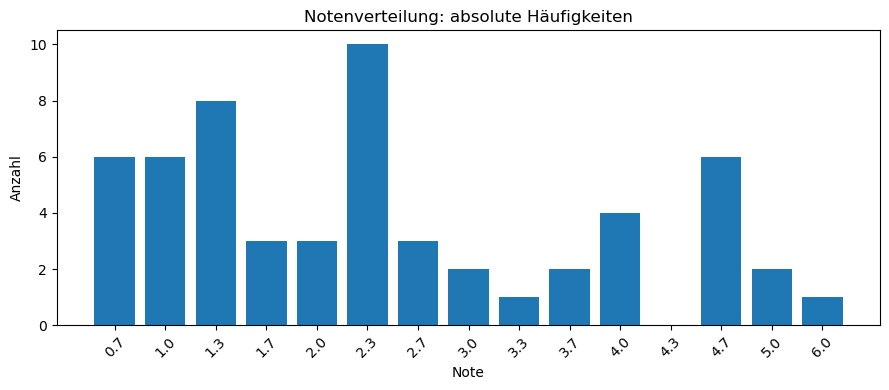

In [11]:
plt.figure(figsize=(9, 4))
plt.bar(freq["Note"].astype(str), freq["Anzahl"])
plt.title("Notenverteilung: absolute Häufigkeiten")
plt.xlabel("Note")
plt.ylabel("Anzahl")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


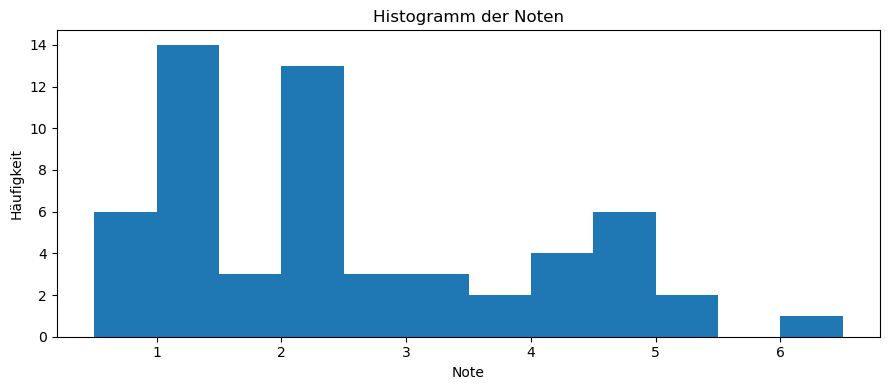

In [12]:
plt.figure(figsize=(9, 4))
plt.hist(df["Note"], bins=np.arange(0.5, 6.6, 0.5))
plt.title("Histogramm der Noten")
plt.xlabel("Note")
plt.ylabel("Häufigkeit")
plt.tight_layout()
plt.show()


## 5. Lage und Streuung

Jetzt berechnen wir die wichtigsten Kennzahlen:

- **Mittelwert:** durchschnittliche Note
- **Median:** mittlerer Wert, wenn alle Noten sortiert sind
- **Minimum und Maximum:** Spannweite der Werte
- **Quartile:** Grenzen für die unteren 25 %, mittleren 50 % und oberen 25 %
- **Interquartilsabstand (IQR):** Streuung der mittleren 50 %
- **Standardabweichung:** typische Abweichung vom Mittelwert


In [13]:
mittelwert = df["Note"].mean()
median = df["Note"].median()
std = df["Note"].std(ddof=1)
varianz = df["Note"].var(ddof=1)
minimum = df["Note"].min()
maximum = df["Note"].max()
spannweite = maximum - minimum
q1 = df["Note"].quantile(0.25)
q3 = df["Note"].quantile(0.75)
iqr = q3 - q1

kennzahlen = pd.DataFrame({
    "Kennzahl": [
        "Anzahl",
        "Mittelwert",
        "Median",
        "Standardabweichung",
        "Varianz",
        "Minimum",
        "1. Quartil",
        "3. Quartil",
        "Interquartilsabstand",
        "Maximum",
        "Spannweite"
    ],
    "Wert": [
        len(df),
        mittelwert,
        median,
        std,
        varianz,
        minimum,
        q1,
        q3,
        iqr,
        maximum,
        spannweite
    ]
})

kennzahlen["Wert"] = kennzahlen["Wert"].round(3)
display(kennzahlen)


,Kennzahl,Wert
0,Anzahl,57.000
1,Mittelwert,2.451
2,Median,2.300
3,Standardabweichung,1.429
4,Varianz,2.041
5,Minimum,0.700
6,1. Quartil,1.300
7,3. Quartil,3.700
8,Interquartilsabstand,2.400
9,Maximum,6.000


### Interpretation

Der Mittelwert kann durch sehr schwache Noten stärker beeinflusst werden als der Median.

Deshalb ist bei Noten oft interessant:

- Liegt der Mittelwert über oder unter dem Median?
- Was sagt das über die Richtung der Verzerrung?
- Wie stark verändern einzelne extreme Werte die Kennzahlen?


In [14]:
print(f"Mittelwert: {mittelwert:.2f}")
print(f"Median:     {median:.2f}")

if mittelwert > median:
    print("Der Mittelwert liegt über dem Median. Schwächere Noten ziehen den Mittelwert nach oben.")
elif mittelwert < median:
    print("Der Mittelwert liegt unter dem Median. Sehr gute Noten ziehen den Mittelwert nach unten.")
else:
    print("Mittelwert und Median sind gleich.")


Mittelwert: 2.45
Median:     2.30
Der Mittelwert liegt über dem Median. Schwächere Noten ziehen den Mittelwert nach oben.


## 6. Boxplot

Ein Boxplot zeigt kompakt:

- Median
- 1. und 3. Quartil
- Streuung der mittleren 50 %
- mögliche Ausreißer

Bei Noten muss man wieder daran denken: **rechts im Plot bedeutet schlechtere Note**.


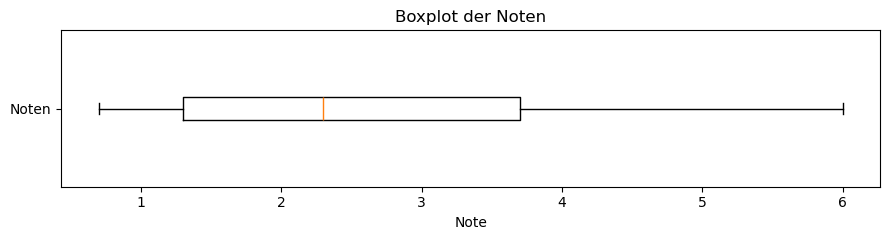

In [15]:
plt.figure(figsize=(9, 2.5))
plt.boxplot(df["Note"], vert=False)
plt.title("Boxplot der Noten")
plt.xlabel("Note")
plt.yticks([1], ["Noten"])
plt.tight_layout()
plt.show()


In [16]:
# Grenzen für mögliche Ausreißer nach der 1.5-IQR-Regel
untere_grenze = q1 - 1.5 * iqr
obere_grenze = q3 + 1.5 * iqr

ausreisser = df[(df["Note"] < untere_grenze) | (df["Note"] > obere_grenze)]

print(f"Untere Grenze nach 1.5-IQR-Regel: {untere_grenze:.2f}")
print(f"Obere Grenze nach 1.5-IQR-Regel:  {obere_grenze:.2f}")
print(f"Anzahl möglicher Ausreißer: {len(ausreisser)}")
display(ausreisser)


Untere Grenze nach 1.5-IQR-Regel: -2.30
Obere Grenze nach 1.5-IQR-Regel:  7.30
Anzahl möglicher Ausreißer: 0


,Note


## 7. Bestanden / nicht bestanden

Für die Qualitätssicherung ist oft nicht nur die genaue Note interessant, sondern auch eine binäre Kennzahl:

- bestanden
- nicht bestanden

Hier verwenden wir die Annahme: **bestanden bis einschließlich 4,0**, **nicht bestanden ab 4,7**.


In [17]:
df["bestanden"] = df["Note"] <= 4.0

bestehens_tabelle = (
    df["bestanden"]
    .value_counts()
    .rename(index={True: "bestanden", False: "nicht bestanden"})
    .rename_axis("Status")
    .reset_index(name="Anzahl")
)

bestehens_tabelle["Anteil_%"] = (100 * bestehens_tabelle["Anzahl"] / len(df)).round(1)

display(bestehens_tabelle)

print(f"Bestehensquote: {(100 * df['bestanden'].mean()):.1f} %")
print(f"Nichtbestehensquote: {(100 * (1 - df['bestanden'].mean())):.1f} %")


,Status,Anzahl,Anteil_%
0,bestanden,48,84.2
1,nicht bestanden,9,15.8


Bestehensquote: 84.2 %
Nichtbestehensquote: 15.8 %


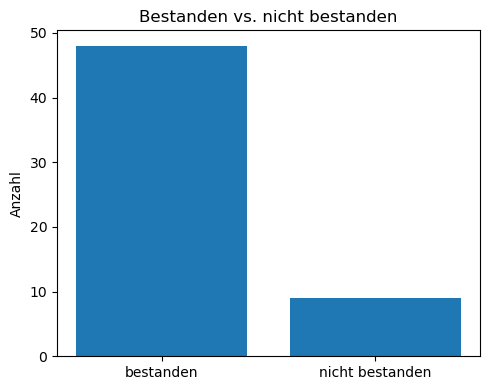

In [18]:
plt.figure(figsize=(5, 4))
plt.bar(bestehens_tabelle["Status"], bestehens_tabelle["Anzahl"])
plt.title("Bestanden vs. nicht bestanden")
plt.ylabel("Anzahl")
plt.tight_layout()
plt.show()


## 8. z-Werte

Ein z-Wert beschreibt, wie viele Standardabweichungen ein Wert vom Mittelwert entfernt liegt.

Für eine Note gilt hier:

\[
z = \frac{x - \bar{x}}{s}
\]

Wichtig: Weil kleinere Noten besser sind, bedeutet ein **negativer z-Wert** hier eine bessere Note als der Durchschnitt. Ein **positiver z-Wert** bedeutet eine schwächere Note als der Durchschnitt.


In [19]:
df["z_Wert"] = (df["Note"] - mittelwert) / std

display(df.sort_values("Note").head(10))
display(df.sort_values("Note", ascending=False).head(10))


,Note,bestanden,z_Wert
43,0.7,True,-1.225417
34,0.7,True,-1.225417
33,0.7,True,-1.225417
37,0.7,True,-1.225417
8,0.7,True,-1.225417
22,0.7,True,-1.225417
1,1.0,True,-1.015451
39,1.0,True,-1.015451
50,1.0,True,-1.015451
9,1.0,True,-1.015451


,Note,bestanden,z_Wert
44,6.0,False,2.483987
16,5.0,False,1.784099
4,5.0,False,1.784099
0,4.7,False,1.574133
17,4.7,False,1.574133
24,4.7,False,1.574133
27,4.7,False,1.574133
32,4.7,False,1.574133
41,4.7,False,1.574133
6,4.0,True,1.084212


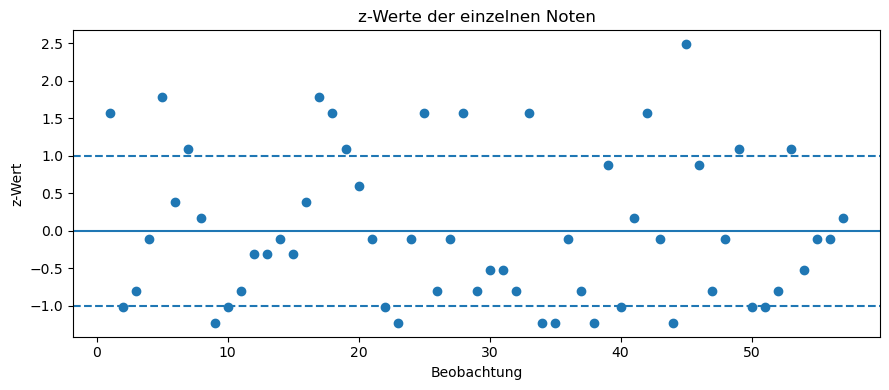

In [20]:
plt.figure(figsize=(9, 4))
plt.scatter(df.index + 1, df["z_Wert"])
plt.axhline(0)
plt.axhline(1, linestyle="--")
plt.axhline(-1, linestyle="--")
plt.title("z-Werte der einzelnen Noten")
plt.xlabel("Beobachtung")
plt.ylabel("z-Wert")
plt.tight_layout()
plt.show()


### Kurze Interpretationsfragen

1. Welche Noten liegen mehr als eine Standardabweichung schlechter als der Durchschnitt?
2. Welche Noten liegen mehr als eine Standardabweichung besser als der Durchschnitt?
3. Warum muss man bei Noten die Richtung der Interpretation besonders beachten?


In [21]:
besser_als_1std = df[df["z_Wert"] < -1].sort_values("Note")
schlechter_als_1std = df[df["z_Wert"] > 1].sort_values("Note", ascending=False)

print("Mehr als eine Standardabweichung besser als der Durchschnitt:")
display(besser_als_1std)

print("Mehr als eine Standardabweichung schlechter als der Durchschnitt:")
display(schlechter_als_1std)


Mehr als eine Standardabweichung besser als der Durchschnitt:


,Note,bestanden,z_Wert
8,0.7,True,-1.225417
22,0.7,True,-1.225417
33,0.7,True,-1.225417
34,0.7,True,-1.225417
37,0.7,True,-1.225417
43,0.7,True,-1.225417
1,1.0,True,-1.015451
9,1.0,True,-1.015451
21,1.0,True,-1.015451
39,1.0,True,-1.015451


Mehr als eine Standardabweichung schlechter als der Durchschnitt:


,Note,bestanden,z_Wert
44,6.0,False,2.483987
4,5.0,False,1.784099
16,5.0,False,1.784099
0,4.7,False,1.574133
17,4.7,False,1.574133
24,4.7,False,1.574133
27,4.7,False,1.574133
32,4.7,False,1.574133
41,4.7,False,1.574133
6,4.0,True,1.084212


## 9. Normalverteilung: nützlich, aber mit Vorsicht

Die Normalverteilung ist ein wichtiges Modell. Für Noten passt sie aber nur eingeschränkt, weil Noten:

- diskret sind,
- nach unten und oben begrenzt sind,
- nicht beliebig fein gemessen werden,
- inhaltlich keine physikalische Messgröße sind.

Trotzdem kann man sie als Vergleichsmodell verwenden, um die Idee von Mittelwert, Standardabweichung und z-Werten zu wiederholen.


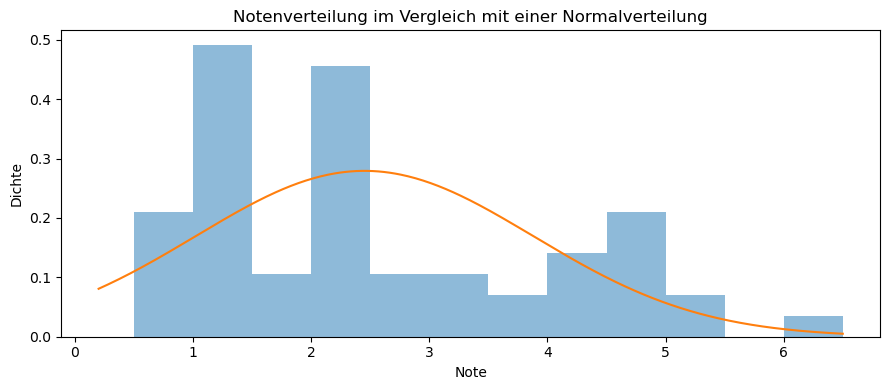

In [22]:
# Normalverteilung mit gleichem Mittelwert und gleicher Standardabweichung wie die Daten
x = np.linspace(df["Note"].min() - 0.5, df["Note"].max() + 0.5, 400)

def normal_density(x, mu, sigma):
    return (1 / (sigma * sqrt(2 * pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

dichte = normal_density(x, mittelwert, std)

plt.figure(figsize=(9, 4))
plt.hist(df["Note"], bins=np.arange(0.5, 6.6, 0.5), density=True, alpha=0.5)
plt.plot(x, dichte)
plt.title("Notenverteilung im Vergleich mit einer Normalverteilung")
plt.xlabel("Note")
plt.ylabel("Dichte")
plt.tight_layout()
plt.show()


In [23]:
def normal_cdf(x, mu, sigma):
    return 0.5 * (1 + erf((x - mu) / (sigma * sqrt(2))))

# Empirischer Anteil nicht bestandener Noten
p_empirisch_nicht_bestanden = (df["Note"] > 4.0).mean()

# Modellierter Anteil nach Normalverteilung
p_normal_nicht_bestanden = 1 - normal_cdf(4.0, mittelwert, std)

print(f"Empirischer Anteil > 4.0:     {100 * p_empirisch_nicht_bestanden:.1f} %")
print(f"Normalmodell-Anteil > 4.0:    {100 * p_normal_nicht_bestanden:.1f} %")
print("\nDas Normalmodell ist hier nur ein Vergleichsmodell, keine perfekte Beschreibung der Realität.")


Empirischer Anteil > 4.0:     15.8 %
Normalmodell-Anteil > 4.0:    13.9 %

Das Normalmodell ist hier nur ein Vergleichsmodell, keine perfekte Beschreibung der Realität.


## 10. Weitere wichtige Verteilungen am Beispiel

### Bernoulli-Verteilung

Wenn wir nur betrachten, ob eine Person bestanden hat oder nicht, ist jede Beobachtung eine Bernoulli-Variable:

- 1 = nicht bestanden
- 0 = bestanden

Die geschätzte Wahrscheinlichkeit für „nicht bestanden“ ist der Anteil der nicht bestandenen Noten in den Daten.


In [24]:
df["nicht_bestanden"] = (df["Note"] > 4.0).astype(int)

p_nicht_bestanden = df["nicht_bestanden"].mean()

print(f"Geschätzte Wahrscheinlichkeit für nicht bestanden: {p_nicht_bestanden:.3f}")
print(f"Also ungefähr: {100 * p_nicht_bestanden:.1f} %")


Geschätzte Wahrscheinlichkeit für nicht bestanden: 0.158
Also ungefähr: 15.8 %


### Binomialverteilung

Wenn man aus einem ähnlichen Semester zufällig 10 Personen betrachtet und für jede Person nur „nicht bestanden“ oder „bestanden“ zählt, kann die Anzahl der nicht bestandenen Personen näherungsweise binomialverteilt modelliert werden.

Das ist eine starke Vereinfachung, aber gut geeignet, um die Idee der Binomialverteilung zu wiederholen.


,k_nicht_bestanden_von_10,Wahrscheinlichkeit,Wahrscheinlichkeit_%
0,0,1.793345e-01,17.9
1,1,3.362522e-01,33.6
2,2,2.837128e-01,28.4
3,3,1.418564e-01,14.2
4,4,4.654663e-02,4.7
5,5,1.047299e-02,1.0
6,6,1.636405e-03,0.2
7,7,1.753291e-04,0.0
8,8,1.232783e-05,0.0
9,9,5.136594e-07,0.0


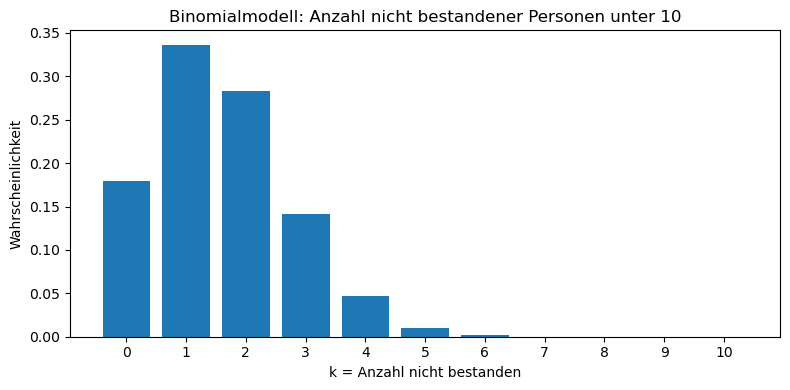

In [25]:
n = 10
k_werte = np.arange(n + 1)

wahrscheinlichkeiten = [
    comb(n, k) * (p_nicht_bestanden ** k) * ((1 - p_nicht_bestanden) ** (n - k))
    for k in k_werte
]

binom_tabelle = pd.DataFrame({
    "k_nicht_bestanden_von_10": k_werte,
    "Wahrscheinlichkeit": wahrscheinlichkeiten,
    "Wahrscheinlichkeit_%": np.round(100 * np.array(wahrscheinlichkeiten), 1)
})

display(binom_tabelle)

plt.figure(figsize=(8, 4))
plt.bar(k_werte, wahrscheinlichkeiten)
plt.title("Binomialmodell: Anzahl nicht bestandener Personen unter 10")
plt.xlabel("k = Anzahl nicht bestanden")
plt.ylabel("Wahrscheinlichkeit")
plt.xticks(k_werte)
plt.tight_layout()
plt.show()


## 11. Sensitivität: Was passiert ohne extreme Werte?

In der Praxis der Qualitätssicherung ist wichtig, ob Kennzahlen robust sind.

Hier prüfen wir, wie sich die Kennzahlen verändern, wenn die schwächste Note entfernt wird.


In [26]:
df_ohne_max = df[df["Note"] < df["Note"].max()].copy()

vergleich = pd.DataFrame({
    "Kennzahl": ["Anzahl", "Mittelwert", "Median", "Standardabweichung", "Maximum"],
    "mit allen Daten": [
        len(df),
        df["Note"].mean(),
        df["Note"].median(),
        df["Note"].std(ddof=1),
        df["Note"].max()
    ],
    "ohne größte Note": [
        len(df_ohne_max),
        df_ohne_max["Note"].mean(),
        df_ohne_max["Note"].median(),
        df_ohne_max["Note"].std(ddof=1),
        df_ohne_max["Note"].max()
    ]
})

vergleich["mit allen Daten"] = vergleich["mit allen Daten"].round(3)
vergleich["ohne größte Note"] = vergleich["ohne größte Note"].round(3)

display(vergleich)


,Kennzahl,mit allen Daten,ohne größte Note
0,Anzahl,57.000,56.000
1,Mittelwert,2.451,2.388
2,Median,2.300,2.300
3,Standardabweichung,1.429,1.358
4,Maximum,6.000,5.000


### Reflexionsfrage

Welche Kennzahl verändert sich stärker: Mittelwert oder Median?

Was bedeutet das für Datensätze mit Ausreißern oder Sonderfällen?


## 12. Mini-Aufgaben

Bearbeitet die Aufgaben direkt im Notebook.

### Aufgabe A: Sehr gute Noten

Berechnet, wie viele Personen eine Note von **1,3 oder besser** erreicht haben.

Zusatz: Berechnet auch den Prozentanteil.


In [27]:
# Aufgabe A
# Tipp: Bei Noten ist "besser" ein kleinerer Wert.
# Ergänzt den Code.

sehr_gut = df[df["Note"] <= 1.3]

print("Anzahl Note 1,3 oder besser:", len(sehr_gut))
print("Anteil in Prozent:", round(100 * len(sehr_gut) / len(df), 1))


Anzahl Note 1,3 oder besser: 20
Anteil in Prozent: 35.1


### Aufgabe B: Mittlerer Bereich

Berechnet, wie viele Noten zwischen **2,0 und 3,0** liegen, jeweils inklusive.


In [28]:
# Aufgabe B

mittlerer_bereich = df[(df["Note"] >= 2.0) & (df["Note"] <= 3.0)]

print("Anzahl Noten zwischen 2,0 und 3,0:", len(mittlerer_bereich))
print("Anteil in Prozent:", round(100 * len(mittlerer_bereich) / len(df), 1))


Anzahl Noten zwischen 2,0 und 3,0: 18
Anteil in Prozent: 31.6


### Aufgabe C: Eigene Qualitätskennzahl

Definiert eine eigene Kennzahl, zum Beispiel:

- Anteil der Noten besser als 2,0
- Anteil der Noten schlechter als 3,7
- Anteil der Noten im Bereich 1,0 bis 2,3

Formuliert kurz, warum diese Kennzahl interessant sein könnte.


In [31]:
# Aufgabe C
# Beispiel: Anteil der Noten besser als 2,0

eigene_kennzahl = (df["Note"] < 2.0).mean()

print("Anteil der Noten besser als 2,0:", round(100 * eigene_kennzahl, 1), "%")


Anteil der Noten besser als 2,0: 40.4 %


## 13. Take-away

Für die Qualitätssicherung ist Statistik nicht nur Rechnen, sondern ein Werkzeug zur strukturierten Beschreibung von Prozessen.

An diesem Beispiel sieht man:

- Häufigkeiten zeigen die konkrete Verteilung.
- Mittelwert und Median beantworten unterschiedliche Fragen.
- Streuung zeigt, wie heterogen die Ergebnisse sind.
- Boxplots helfen, Verteilung und mögliche Ausreißer schnell zu erkennen.
- z-Werte beschreiben relative Abweichungen vom Durchschnitt.
- Normalverteilungen sind wichtige Modelle, passen aber nicht automatisch zu jedem Datentyp.
- Bernoulli- und Binomialverteilungen helfen, Ja/Nein-Ereignisse und Häufigkeiten solcher Ereignisse zu modellieren.
